In [1]:
qweruiop[import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('auto_imports.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   3            200 non-null    int64  
 1   ?            200 non-null    object 
 2   alfa-romero  200 non-null    object 
 3   gas          200 non-null    object 
 4   std          200 non-null    object 
 5   two          200 non-null    object 
 6   convertible  200 non-null    object 
 7   rwd          200 non-null    object 
 8   front        200 non-null    object 
 9   88.60        200 non-null    float64
 10  168.80       200 non-null    float64
 11  64.10        200 non-null    float64
 12  48.80        200 non-null    float64
 13  2548         200 non-null    int64  
 14  dohc         200 non-null    object 
 15  four         200 non-null    object 
 16  130          200 non-null    int64  
 17  mpfi         200 non-null    object 
 18  3.47         200 non-null    object 
 19  2.68    

In [5]:
df.head(5)

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


### Adding column

In [6]:
columns = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style', 'drive_wheels',
    'engine_location', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type', 'num_of_cylinders',
    'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 
    'highway_mpg', 'price'
]

In [7]:
# since there is no column so header is set to None so first row will not be treated 
# as header
# And names mean what are define column Name

df = pd.read_csv('auto_imports.csv', header = None, names = columns)
df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [8]:
df = pd.read_csv('auto_imports.csv', header = None, names = columns, na_values=['?'])
df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [9]:
df.isnull().sum()

symboling             0
normalized_losses    37
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

In [10]:
df.head(20)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875
9,2,192.0,bmw,gas,std,two,sedan,rwd,front,101.2,176.8,64.8,54.3,2395,ohc,four,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29,16430


In [11]:
# in 'num-of-cylinders' column the data are in two four instead of 2 4 
# change two --> 2
# using mapping
word_to_num = {
    "two" : 2, "three" : 3, "four" : 4 , "five" : 5 , "six" : 6, "eight" : 8, "twelve" : 12
}

df["num_of_cylinders"] = df["num_of_cylinders"].map(word_to_num)

In [12]:
df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


### Converting two four into 2 4 in num_of_doors

In [13]:
# filling NaN in num of door column 
mode_by_style = df.groupby('body_style')['num_of_doors'].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else np.nan
)
df['num_of_doors'] = df.apply(
    lambda r: mode_by_style[r['body_style']] if pd.isnull(r['num_of_doors']) else r['num_of_doors']
    ,axis = 1
)
door_map = {"two": 2, "four": 4}
df["num_of_doors"] = df["num_of_doors"].map(door_map)




In [14]:
for c in ['normalized_losses', 'price', 'peak_rpm', 'horsepower', 'bore','stroke']:
    df[c] = df[c].fillna(df[c].median())

In [15]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,115.0,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    float64
 2   make               201 non-null    object 
 3   fuel_type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num_of_doors       201 non-null    int64  
 6   body_style         201 non-null    object 
 7   drive_wheels       201 non-null    object 
 8   engine_location    201 non-null    object 
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    object 
 15  num_of_cylinders   201 non-null    int64  
 16  engine_size        201 non

### changing data type to correct dtype

In [17]:
numeric_dtype = ['normalized_losses', 'peak_rpm', 'horsepower']

for c in numeric_dtype:
    df[c] = pd.to_numeric(df[c], errors= "coerce")
    df[c] = df[c].astype("int64")

In [18]:
df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,115,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [19]:
df.iloc[60:66]

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
60,0,115,mazda,diesel,std,4,sedan,fwd,front,98.8,177.8,66.5,55.5,2443,ohc,4,122,idi,3.39,3.39,22.7,64,4650,36,42,10795
61,0,115,mazda,gas,std,4,hatchback,fwd,front,98.8,177.8,66.5,55.5,2425,ohc,4,122,2bbl,3.39,3.39,8.6,84,4800,26,32,11245
62,0,118,mazda,gas,std,4,sedan,rwd,front,104.9,175.0,66.1,54.4,2670,ohc,4,140,mpfi,3.76,3.16,8.0,120,5000,19,27,18280
63,0,115,mazda,diesel,std,4,sedan,rwd,front,104.9,175.0,66.1,54.4,2700,ohc,4,134,idi,3.43,3.64,22.0,72,4200,31,39,18344
64,-1,93,mercedes-benz,diesel,turbo,4,sedan,rwd,front,110.0,190.9,70.3,56.5,3515,ohc,5,183,idi,3.58,3.64,21.5,123,4350,22,25,25552
65,-1,93,mercedes-benz,diesel,turbo,4,wagon,rwd,front,110.0,190.9,70.3,58.7,3750,ohc,5,183,idi,3.58,3.64,21.5,123,4350,22,25,28248


In [20]:
df.isnull().sum().sum()

0

### Till here all empty cell are filled and null value is zero

### Outlier

#### will work outlier later

### Train Test Split

In [21]:
x = df.drop('price', axis = 1)
y = df['price']

In [22]:
display(x)
display(y)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27
1,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,1,115,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26
3,2,164,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102,5500,24,30
4,2,164,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,4,141,mpfi,3.78,3.15,9.5,114,5400,23,28
197,-1,95,volvo,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,4,141,mpfi,3.78,3.15,8.7,160,5300,19,25
198,-1,95,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,6,173,mpfi,3.58,2.87,8.8,134,5500,18,23
199,-1,95,volvo,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,6,145,idi,3.01,3.40,23.0,106,4800,26,27


0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
196    16845
197    19045
198    21485
199    22470
200    22625
Name: price, Length: 201, dtype: int64

In [23]:
numerical_column = x.select_dtypes(include = np.number).columns.to_list()
display(numerical_column)

['symboling',
 'normalized_losses',
 'num_of_doors',
 'wheel_base',
 'length',
 'width',
 'height',
 'curb_weight',
 'num_of_cylinders',
 'engine_size',
 'bore',
 'stroke',
 'compression_ratio',
 'horsepower',
 'peak_rpm',
 'city_mpg',
 'highway_mpg']

In [24]:
categorical_column = x.select_dtypes(exclude= np.number).columns.to_list()
display(categorical_column)

['make',
 'fuel_type',
 'aspiration',
 'body_style',
 'drive_wheels',
 'engine_location',
 'engine_type',
 'fuel_system']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)

### Standard scalers

In [26]:
scaler = StandardScaler()

x_train_scaler = scaler.fit_transform(x_train[numerical_column])
x_test_scaler = scaler.transform(x_test[numerical_column])

In [27]:
display(x_train_scaler)
display(x_test_scaler)

array([[-1.43486011, -0.77616889,  0.80590603, ...,  0.77645019,
        -1.15657364, -1.16471216],
       [-0.61494005, -1.08371476,  0.80590603, ...,  1.40706964,
         0.27056093,  0.33451508],
       [ 0.20498002,  0.85382423,  0.80590603, ...,  0.77645019,
         0.90484296,  1.08412869],
       ...,
       [ 0.20498002,  0.23873248, -1.24083945, ...,  0.14583075,
         0.90484296,  0.93420597],
       [ 1.02490008,  0.05420496, -1.24083945, ...,  0.25093399,
         0.27056093,  0.4844378 ],
       [ 1.84482014,  2.26853524, -1.24083945, ...,  0.14583075,
        -1.31514415, -1.16471216]])

array([[ 1.02490008,  1.46891597, -1.24083945, -0.62038501, -0.96888139,
        -0.9957769 , -0.21953574, -1.08387091, -0.30855869, -0.69861044,
        -0.63853104,  0.12511517, -0.16292518, -0.92026899,  0.14583075,
         0.90484296,  0.93420597],
       [-0.61494005, -0.16107715, -1.24083945,  0.80417923,  1.64828087,
         1.04556575, -0.05635006,  1.71413632,  1.62749582,  2.12737129,
         1.0862367 ,  0.43888364, -0.53604899,  2.24956591,  0.56624371,
        -1.47371466, -1.31463488],
       [ 1.02490008,  0.51552377, -1.24083945, -2.06190834, -2.45249566,
        -0.94598806, -1.23944626, -1.46931069, -0.30855869, -0.82477034,
        -1.5192635 ,  0.50163733, -0.21622858, -0.72390754,  1.8274826 ,
         0.90484296,  1.08412869],
       [-0.61494005, -0.89918724,  0.80590603, -0.51863042, -0.64381983,
        -0.69704383, -0.42351784, -0.81467488, -0.30855869, -0.67337846,
        -0.49174229, -0.69068283, -0.26953198, -0.89221736, -0.69499518,
         0.42913144

### Feature Encoding

In [28]:
df[numerical_column].corr()

,symboling,normalized_losses,num_of_doors,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
symboling,1.000000,0.457735,-0.672344,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.118016,-0.110581,-0.142547,-0.004387,-0.182196,0.075486,0.279897,-0.035527,0.036233
normalized_losses,0.457735,1.000000,-0.355303,-0.075109,-0.009116,0.061799,-0.371830,0.065393,0.080549,0.073586,-0.052094,0.046024,-0.115967,0.182479,0.245899,-0.193896,-0.150773
num_of_doors,-0.672344,-0.355303,1.000000,0.445245,0.395122,0.227655,0.538383,0.208517,0.002225,0.024094,0.120915,-0.010194,0.169164,-0.102504,-0.232247,-0.027617,-0.045787
wheel_base,-0.535987,-0.075109,0.445245,1.000000,0.876024,0.814507,0.590742,0.782097,0.348931,0.572027,0.494065,0.156740,0.250313,0.372156,-0.360946,-0.470606,-0.543304
length,-0.365404,-0.009116,0.395122,0.876024,1.000000,0.857170,0.492063,0.880665,0.440348,0.685025,0.609557,0.123016,0.159733,0.578683,-0.285301,-0.665192,-0.698142
width,-0.242423,0.061799,0.227655,0.814507,0.857170,1.000000,0.306002,0.866201,0.520118,0.729436,0.544986,0.188605,0.189867,0.614146,-0.245273,-0.633531,-0.680635
height,-0.550160,-0.371830,0.538383,0.590742,0.492063,0.306002,1.000000,0.307581,0.007776,0.074694,0.182946,-0.064380,0.259737,-0.086078,-0.310513,-0.049800,-0.104812
curb_weight,-0.233118,0.065393,0.208517,0.782097,0.880665,0.866201,0.307581,1.000000,0.604454,0.849072,0.644434,0.166809,0.156433,0.757961,-0.279429,-0.749543,-0.794889
num_of_cylinders,-0.118016,0.080549,0.002225,0.348931,0.440348,0.520118,0.007776,0.604454,1.000000,0.847639,0.205936,0.008480,-0.018138,0.669385,-0.152422,-0.439432,-0.473746
engine_size,-0.110581,0.073586,0.024094,0.572027,0.685025,0.729436,0.074694,0.849072,0.847639,1.000000,0.574504,0.203043,0.028889,0.822167,-0.256503,-0.650546,-0.679571


* converting categorical column into Numerical Column

In [29]:
encoding = OneHotEncoder()

In [30]:
x_train_OneHotEnc = encoding.fit_transform(x_train[categorical_column])
x_test_OneHotEnc = encoding.transform(x_test[categorical_column])

In [31]:
display(pd.DataFrame(x_train_OneHotEnc))

,0
0,"(0, 21)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0..."
1,"(0, 5)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0\..."
2,"(0, 4)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0\..."
3,"(0, 15)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0..."
4,"(0, 21)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0..."
...,...
155,"(0, 13)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0..."
156,"(0, 2)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0\..."
157,"(0, 12)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0..."
158,"(0, 20)\t1.0\n (0, 23)\t1.0\n (0, 24)\t1.0..."


the above data are in 0 dimensional , this is wrong . data did not spread in array

so applying sparse_output = False

In [32]:
encoding = OneHotEncoder(handle_unknown= 'ignore', sparse_output=False)


In [33]:
# doing once 

x_train_OneHotEnc = encoding.fit_transform(x_train[categorical_column])
x_test_OneHotEnc = encoding.transform(x_test[categorical_column])

In [34]:
display(pd.DataFrame(x_train_OneHotEnc))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
156,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Combining x_train scaler and x_train Encoding to make final

In [35]:
x_train_final = np.hstack([x_train_scaler, x_train_OneHotEnc])
x_test_final = np.hstack([x_test_scaler, x_test_OneHotEnc])

In [36]:
print(x_train_final.shape)
print(x_test_final.shape)

(160, 67)
(41, 67)


### [x_train_final & x_test_final ] ..is the final data for x_train


### Model Building

In [37]:
models = {
    'AdaBoost Regressor' : AdaBoostRegressor(),
    'CatBoosting Regressor' : CatBoostRegressor(verbose = False),
    'Decision Tree' : DecisionTreeRegressor(),
    'K-Neighbors Regressor' : KNeighborsRegressor(),
    'Lasso' : Lasso(),
    'Linear Regression' : LinearRegression(),
    'Random Forest Regressor' : RandomForestRegressor(),
    'Ridge' :Ridge(),
    'XGBRegressor' : XGBRegressor()
}

In [38]:
# defining evaluation matrics

def evaluation(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [39]:
model_list = []
r2_list = []
pred_list = {}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train_final, y_train)

    
    y_train_pred = model.predict(x_train_final)
    y_test_pred = model.predict(x_test_final)


    model_train_mae, model_train_rmse, model_train_r2 = evaluation(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluation(y_test, y_test_pred)


    print('----------------------------------')
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    print('----------------------------------')

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))


    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)


----------------------------------
AdaBoost Regressor
----------------------------------
Model performance for Training set
- Root Mean Squared Error: 1532.3232
- Mean Absolute Error: 1269.3137
- R2 Score: 0.9485
Model performance for Test set
- Root Mean Squared Error: 2983.7900
- Mean Absolute Error: 2273.5707
- R2 Score: 0.9272
Learning rate set to 0.03065
0:	learn: 6659.7666455	total: 61.7ms	remaining: 1m 1s
1:	learn: 6549.8276690	total: 62.8ms	remaining: 31.3s
2:	learn: 6452.9842549	total: 63.9ms	remaining: 21.2s
3:	learn: 6341.9022875	total: 65ms	remaining: 16.2s
4:	learn: 6232.8484303	total: 66.5ms	remaining: 13.2s
5:	learn: 6139.1844525	total: 67.4ms	remaining: 11.2s
6:	learn: 6034.3542923	total: 68.4ms	remaining: 9.71s
7:	learn: 5943.2518803	total: 69.3ms	remaining: 8.59s
8:	learn: 5857.0656647	total: 70.2ms	remaining: 7.73s
9:	learn: 5753.4501541	total: 71.2ms	remaining: 7.05s
10:	learn: 5667.0509359	total: 72.3ms	remaining: 6.5s
11:	learn: 5559.1058544	total: 73.1ms	remainin

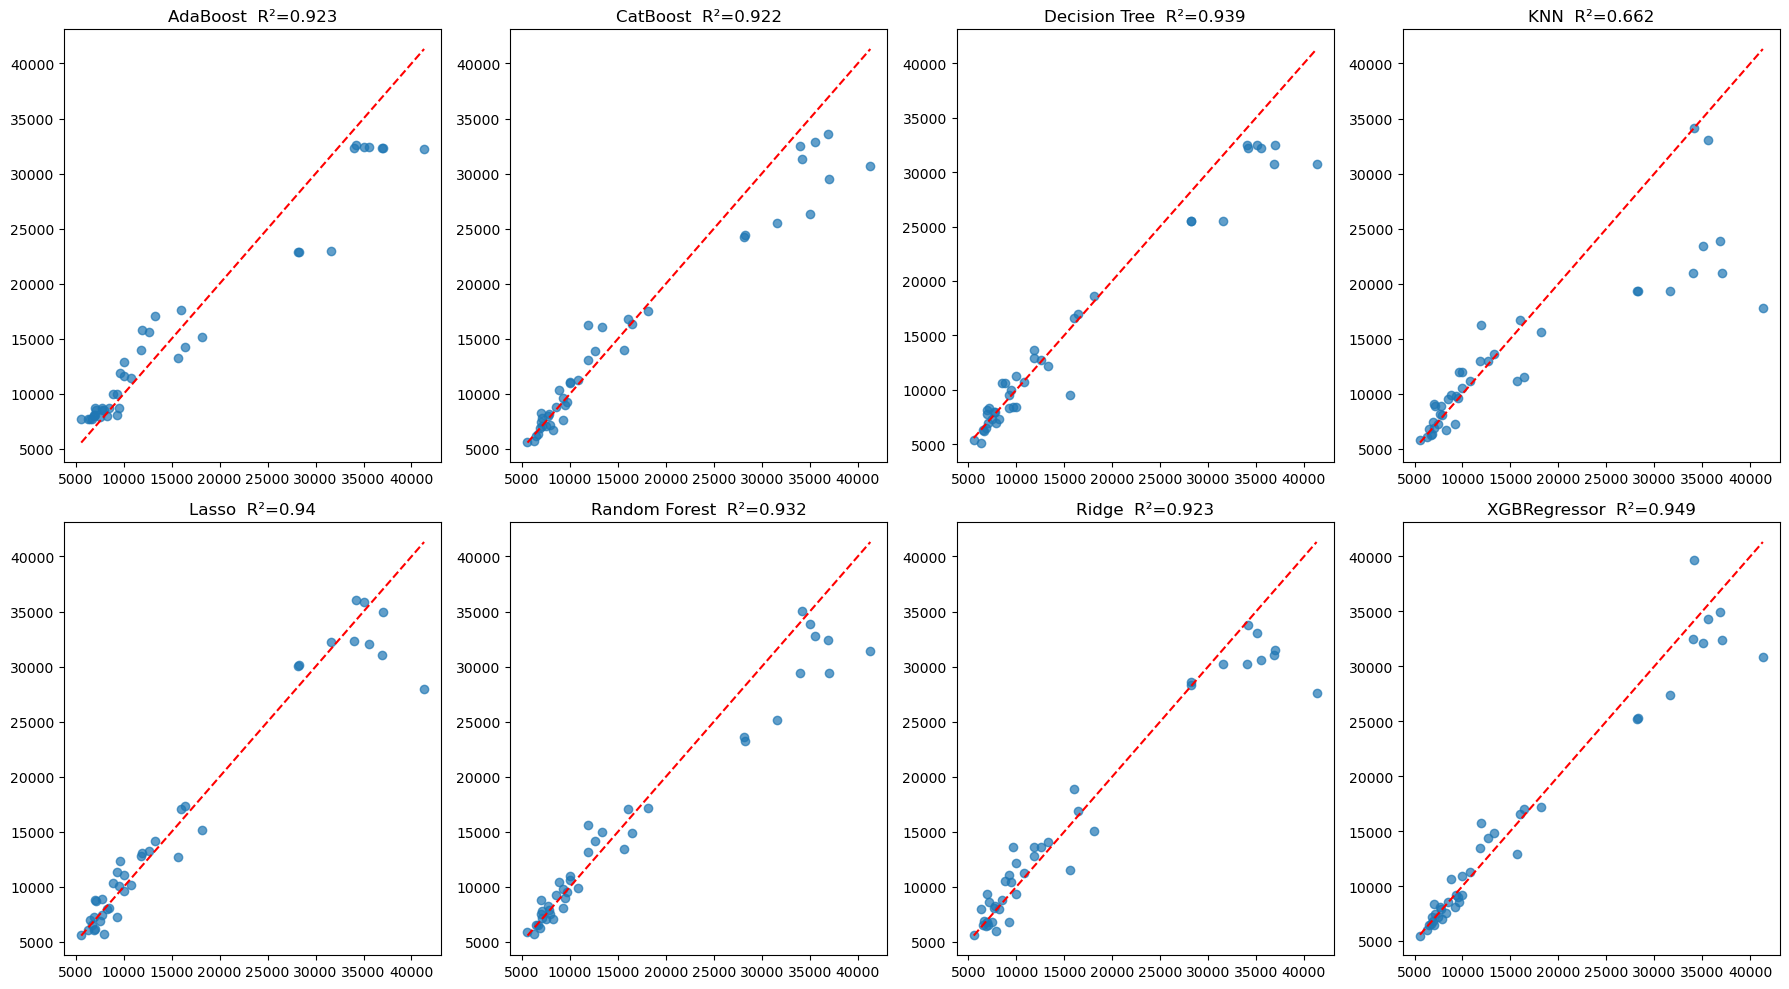

In [40]:
plot_model = {
    "AdaBoost"      : AdaBoostRegressor(),
    "CatBoost"      : CatBoostRegressor(verbose=False),
    "Decision Tree" : DecisionTreeRegressor(),
    "KNN"           : KNeighborsRegressor(),
    "Lasso"         : Lasso(),
    "Random Forest" : RandomForestRegressor(),
    "Ridge"         : Ridge(),
    "XGBRegressor"  : XGBRegressor(),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()


for ax, (name, model) in zip(axes, plot_model.items()):
    model.fit(x_train_final, y_train)
    preds = model.predict(x_test_final)
    r2    = round(r2_score(y_test, preds), 3)

    ax.scatter(y_test, preds, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--")
    ax.set_title(f"{name}  R²={r2}")

plt.tight_layout()
plt.show()

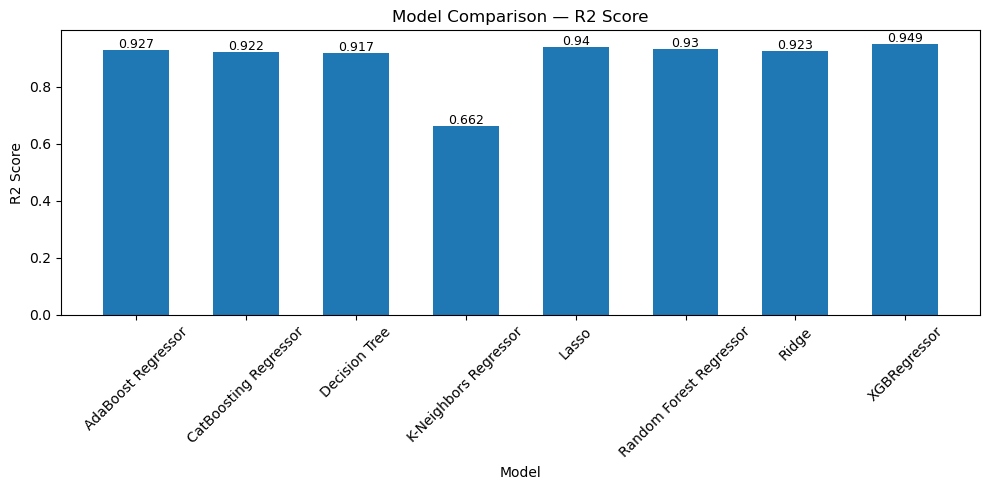

In [41]:
clean_models = [(m, r) for m, r in zip(model_list, r2_list) if m != "Linear Regression"]

plt.figure(figsize=(10, 5))
bars = plt.bar([m for m, r in clean_models], 
                [r for m, r in clean_models],width=0.6 )

for bar, (m, r) in zip(bars, clean_models):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.007,
             str(round(r, 3)), 
             ha="center", fontsize=9)



plt.title("Model Comparison — R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cross-Validation

In [42]:
cv_score={}
for name, model in plot_model.items():
    scores = cross_val_score(model, x_train_final, y_train, cv=5, scoring="r2")
    print(f"{name:20s}  CV R2: {round(scores.mean(), 3)}  Std: {round(scores.std(), 3)}")
    cv_score[name] = round(scores.mean(), 3)
    

AdaBoost              CV R2: 0.83  Std: 0.052
CatBoost              CV R2: 0.861  Std: 0.048
Decision Tree         CV R2: 0.801  Std: 0.058
KNN                   CV R2: 0.751  Std: 0.086
Lasso                 CV R2: 0.817  Std: 0.056
Random Forest         CV R2: 0.854  Std: 0.048
Ridge                 CV R2: 0.859  Std: 0.039
XGBRegressor          CV R2: 0.809  Std: 0.073


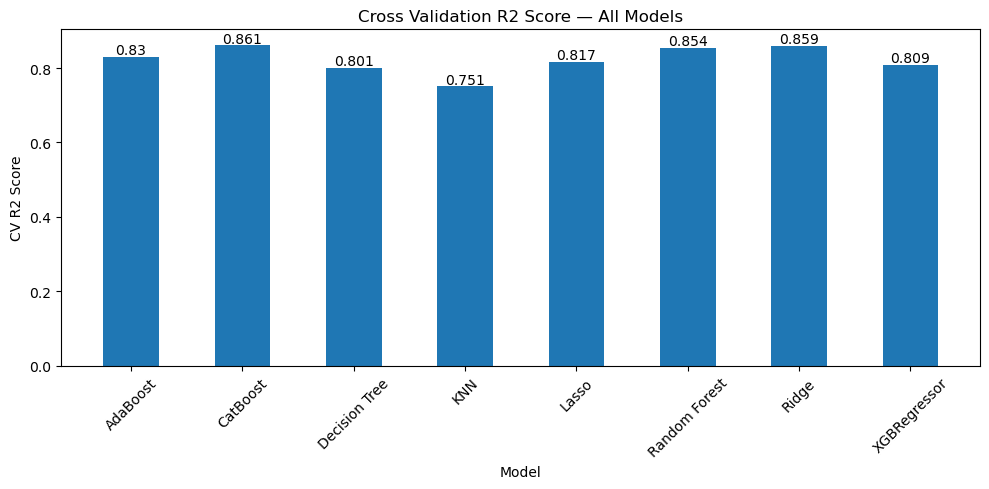

In [43]:
plt.figure(figsize=(10, 5))
plt.bar(cv_score.keys(), cv_score.values(), width=0.5)

for i, (name, score) in enumerate(cv_score.items()):
    plt.text(i, score + 0.007, str(score), ha="center", fontsize=10)
    

plt.title("Cross Validation R2 Score — All Models")
plt.xlabel("Model")
plt.ylabel("CV R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

Performing Hyperparameter tuning on **all** model.

In [44]:
from sklearn.model_selection import GridSearchCV

In [57]:
param_grid = {
    "AdaBoost" : (
        AdaBoostRegressor(),
        {
            "n_estimators" : [50, 100, 200],
            "learning_rate" : [0.01, 0.1, 0.5, 1.0],
        }
    ),
    'CatBoost' : (
        CatBoostRegressor(verbose = False),
        {
            'iterations' : [500, 1000, 1500],
            'learning_rate' : [0.01, 0.3, 0.1],
            'depth': [4,6,8]
        }
    ),
    'Decision Tree' : (
        DecisionTreeRegressor(),
        {
            'max_depth' : [3, 5, 7, 10],
            'min_samples_split' : [2,5,10]
        }
    ),
    "KNN" : (
        KNeighborsRegressor(),
        {
            'n_neighbors' : [3, 5, 7, 10],
            'weights' : ['uniform', 'distance'],
        }
    ),
    'Lasso' : (
        Lasso(max_iter = 100000, tol=0.01),
        {
            'alpha' : [0.001, 0.01, 0.1, 1.0, 10.0],
        }
    ),
    "Ridge": (
        Ridge(),
        {
            "alpha": [0.1, 1.0, 10.0, 100.0],
        }
    ),
    "XGBoost": (
        XGBRegressor(),
        {
            "n_estimators" : [100, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth"    : [3, 5, 7],
        }
    ),
}

In [58]:
best_models = {}

for name, (model, params) in param_grid.items():
    grid = GridSearchCV(model, params, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(x_train_final, y_train)

    best_models[name] = grid.best_estimator_

    preds  = grid.best_estimator_.predict(x_test_final)
    test_r2 = round(r2_score(y_test, preds), 3)

    print(f"── {name} ──")
    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R2  : {round(grid.best_score_, 3)}")
    print(f"Test R2     : {test_r2}")
    print()

── AdaBoost ──
Best Params : {'learning_rate': 0.1, 'n_estimators': 200}
Best CV R2  : 0.847
Test R2     : 0.925

── CatBoost ──
Best Params : {'depth': 4, 'iterations': 1500, 'learning_rate': 0.01}
Best CV R2  : 0.878
Test R2     : 0.932

── Decision Tree ──
Best Params : {'max_depth': 7, 'min_samples_split': 10}
Best CV R2  : 0.819
Test R2     : 0.93

── KNN ──
Best Params : {'n_neighbors': 3, 'weights': 'distance'}
Best CV R2  : 0.783
Test R2     : 0.756

── Lasso ──
Best Params : {'alpha': 10.0}
Best CV R2  : 0.846
Test R2     : 0.934

── Ridge ──
Best Params : {'alpha': 1.0}
Best CV R2  : 0.859
Test R2     : 0.923

── XGBoost ──
Best Params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV R2  : 0.867
Test R2     : 0.956



XGBoost best model

In [59]:
final_model = XGBRegressor(
    learning_rate = 0.05,
    max_depth = 3,
    n_estimators = 300
)

final_model.fit(x_train_final, y_train)

y_train_pred = final_model.predict(x_train_final)
y_test_pred = final_model.predict(x_test_final)

train_mae, train_rmse, train_r2 = evaluation(y_train, y_train_pred)
test_mae,  test_rmse,  test_r2  = evaluation(y_test,  y_test_pred)

print(" XGBoost Final Model ")
print("Train R2  :", round(train_r2,   3))
print("Train RMSE:", round(train_rmse, 1))
print("Train MAE :", round(train_mae,  1))
print()
print("Test R2   :", round(test_r2,   3))
print("Test RMSE :", round(test_rmse, 1))
print("Test MAE  :", round(test_mae,  1))

 XGBoost Final Model 
Train R2  : 0.993
Train RMSE: 578.7
Train MAE : 438.8

Test R2   : 0.956
Test RMSE : 2325.3
Test MAE  : 1486.6


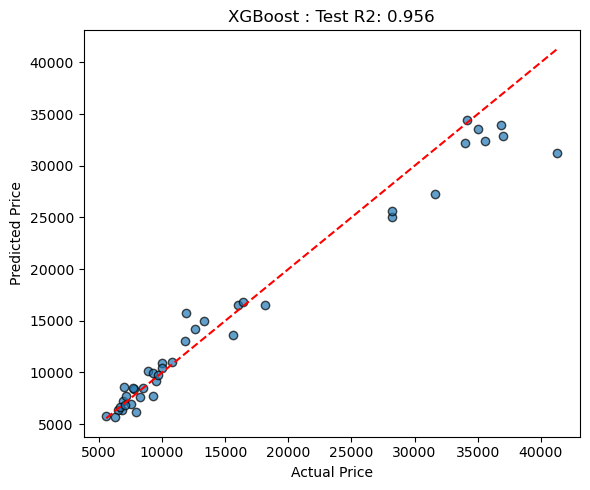

In [61]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred, alpha=0.7, edgecolor="k")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"XGBoost : Test R2: {round(test_r2, 3)}")
plt.tight_layout()
plt.show()

## Feature Importance:

In [62]:
feature_col = encoding.get_feature_names_out(categorical_column)

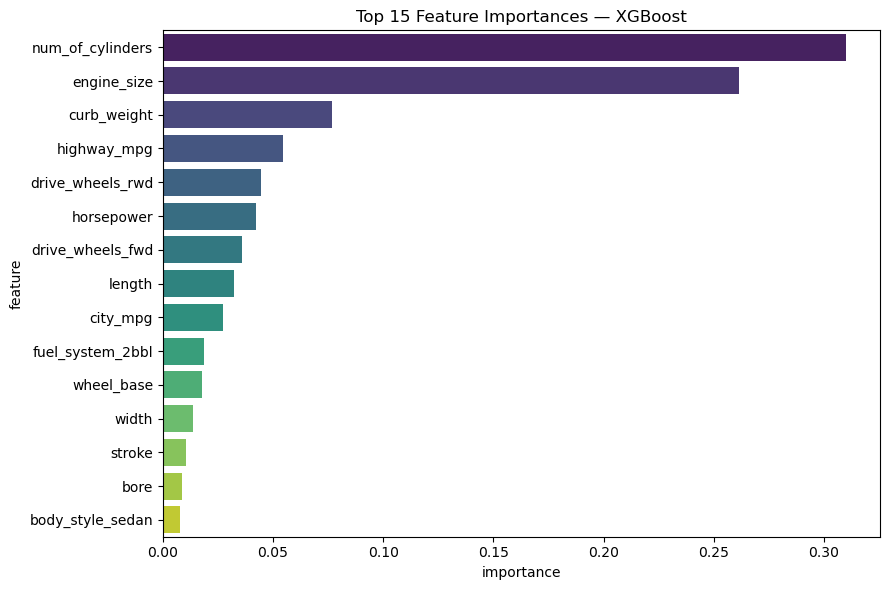

In [65]:
all_features = numerical_column + list(feature_col)

fi_df = pd.DataFrame({
    "feature"   : all_features,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi_df, y="feature", x="importance", palette="viridis")
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

### saving model

In [67]:
import pickle
with open('car_price_model.pkl','wb') as f:
    pickle.dump(final_model, f)

print('model saved')

model saved


### testing model

In [68]:
with open('car_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [83]:
new_car = x_test_final[0].reshape(1, -1)

predicted_price = loaded_model.predict(new_car)
actual_price = y_test.values[0]

print(f'Actual Price : {actual_price}')
print(f'Predicted Price: {round(predicted_price[0])}')
print(f'Difference : {(actual_price - round(predicted_price[0]))}')

Actual Price : 8249
Predicted Price: 7675
Difference : 574


In [77]:
# ek naya car manually banao
new_car_data = pd.DataFrame([{
    "symboling"        : 0,
    "normalized_losses": 100,
    "make"             : "toyota",
    "fuel_type"        : "gas",
    "aspiration"       : "std",
    "num_of_doors"     : 4,
    "body_style"       : "sedan",
    "drive_wheels"     : "fwd",
    "engine_location"  : "front",
    "wheel_base"       : 98.0,
    "length"           : 170.0,
    "width"            : 65.0,
    "height"           : 54.0,
    "curb_weight"      : 2400,
    "engine_type"      : "ohc",
    "num_of_cylinders" : 4,
    "engine_size"      : 110,
    "fuel_system"      : "mpfi",
    "bore"             : 3.19,
    "stroke"           : 3.40,
    "compression_ratio": 10.0,
    "horsepower"       : 102,
    "peak_rpm"         : 5500,
    "city_mpg"         : 24,
    "highway_mpg"      : 30,
}])

# same scaling aur encoding apply karo
new_scaled = scaler.transform(new_car_data[numerical_column])
new_encoder    = encoding.transform(new_car_data[categorical_column])
new_final  = np.hstack([new_scaled, new_encoder])

# predict
price = loaded_model.predict(new_final)
print("Predicted Price: $", round(price[0], 0))

Predicted Price: $ 10346.0
